# Diabetic Retinopathy Grading
Train EfficientNet-B5 on the preprocessed dataset with stratified splits and weighted sampling.


In [1]:
import os

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T

import timm
from sklearn.model_selection import train_test_split

from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.amp import GradScaler, autocast

import json
import csv
import time
import datetime

from sklearn.metrics import cohen_kappa_score, confusion_matrix
from tqdm.auto import tqdm

import matplotlib.pyplot as plt


/user/HS400/zv00033/miniconda3/envs/diab/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Load Labels & Filter to Existing Images

In [3]:
TRAIN_DIR = Path("dataset/train")
LABELS_CSV = Path("trainLabels.csv")
NUM_CLASSES = 5
IMG_SIZE = 456

df = pd.read_csv(LABELS_CSV)
# Build full file paths and keep only rows whose images actually exist
df["filepath"] = df["image"].apply(lambda x: str(TRAIN_DIR / f"{x}.jpeg"))
df = df[df["filepath"].apply(os.path.exists)].reset_index(drop=True)

print(f"Total images found: {len(df)}")
print(f"\nClass distribution:\n{df['level'].value_counts().sort_index()}")

Total images found: 35122

Class distribution:
level
0    25808
1     2442
2     5291
3      873
4      708
Name: count, dtype: int64


## 2. Stratified Train / Val / Test Split (70 / 10 / 20)

In [4]:
# First split: 70% train, 30% temp (which becomes 20% test + 10% val)
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["level"], random_state=42)

# Second split: split the 30% into 20% test and 10% val (2/3 and 1/3 of 30%)
test_df, val_df = train_test_split(temp_df, test_size=1/3, stratify=temp_df["level"], random_state=42)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Train: {len(train_df)}  Test: {len(test_df)}  Val: {len(val_df)}")
print(f"\nTrain class distribution:\n{train_df['level'].value_counts().sort_index()}")
print(f"\nTest class distribution:\n{test_df['level'].value_counts().sort_index()}")
print(f"\nVal class distribution:\n{val_df['level'].value_counts().sort_index()}")

Train: 24585  Test: 7024  Val: 3513

Train class distribution:
level
0    18065
1     1709
2     3704
3      611
4      496
Name: count, dtype: int64

Test class distribution:
level
0    5161
1     489
2    1058
3     175
4     141
Name: count, dtype: int64

Val class distribution:
level
0    2582
1     244
2     529
3      87
4      71
Name: count, dtype: int64


## 3. Loss
Treating the problem as regression with MSELoss on a single-output head.
No WeightedRandomSampler: under MSE, oversampling minority classes shifts the
target distribution itself and biases predictions upward — MSE's quadratic
penalty already aligns with QWK's quadratic weights, so we rely on the natural
class distribution instead.


In [5]:
class_counts = train_df["level"].value_counts().sort_index().values

#Treat grading as regression on a single scalar output in [0, NUM_CLASSES-1]
#Plain MSE for validation/test reporting (keeps val_loss comparable across runs)
criterion = nn.MSELoss()

#Sample-weighted MSE for training: penalize errors on minority classes more heavily.
class_counts_t = torch.tensor(class_counts, dtype=torch.float32, device=device)
N_total = class_counts_t.sum()
K = NUM_CLASSES
class_weights = (N_total / (K * class_counts_t)).sqrt()  # shape: [NUM_CLASSES]

print(f"Class counts (natural distribution kept, no sampler): {dict(enumerate(class_counts))}")
print(f"Class weights (sqrt inverse freq):                    {class_weights.cpu().tolist()}")
print("Loss: Sample-weighted MSE for training, MSE for validation/test")


Class counts (natural distribution kept, no sampler): {0: np.int64(18065), 1: np.int64(1709), 2: np.int64(3704), 3: np.int64(611), 4: np.int64(496)}
Class weights (sqrt inverse freq):                    [0.5217123627662659, 1.696207880973816, 1.1521648168563843, 2.8368051052093506, 3.1485402584075928]
Loss: Sample-weighted MSE for training, MSE for validation/test


## 4. Custom Dataset & Data Augmentations

In [6]:
class DRDatasetFromPaths(Dataset):
    """Dataset that loads images from disk. Labels are returned as float for regression."""

    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert("RGB")
        label = float(self.labels[idx])
        if self.transform:
            image = self.transform(image)
        return image, label


### Tranforming the datasets

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]       #ImageNet normalization for pretrained EfficientNet
IMAGENET_STD = [0.229, 0.224, 0.225]       #ImageNet normalization for pretrained EfficientNet

train_transform = T.Compose([
    T.RandomRotation(degrees=360),          #Allowing images to be rotated 360 degrees
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# --- Build datasets -------------------------------------------------------
train_dataset = DRDatasetFromPaths(train_df["filepath"].tolist(), train_df["level"].tolist(), transform=train_transform)
test_dataset = DRDatasetFromPaths(test_df["filepath"].tolist(), test_df["level"].tolist(), transform=eval_transform)
val_dataset = DRDatasetFromPaths(val_df["filepath"].tolist(), val_df["level"].tolist(), transform=eval_transform)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")


Train dataset size: 24585
Test dataset size: 7024
Val dataset size: 3513


## 5. DataLoaders

Load the datasets into each variable - train_loader, val_loader, test_loader for training and testing.

In [8]:
BATCH_SIZE = 16                                     # hit hardware limit                              
ACCUM_STEPS = 4                                   # gradient accumulation steps
EFFECTIVE_BATCH_SIZE = BATCH_SIZE * ACCUM_STEPS   # 16 * 4 = 64
NUM_WORKERS = 4

#Natural class distribution under MSE (no WeightedRandomSampler)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Micro batch: {BATCH_SIZE}  |  Accum steps: {ACCUM_STEPS}  |  Effective batch: {EFFECTIVE_BATCH_SIZE}")

Micro batch: 16  |  Accum steps: 4  |  Effective batch: 64


## 6. Load EfficientNet-B5 from timm

In [9]:
#Single-output regression head: predict a continuous DR grade in [0, NUM_CLASSES-1]
model = timm.create_model("efficientnet_b5", pretrained=True, num_classes=1)
model = model.to(device)

print(model.default_cfg["input_size"])      #Expected input size of model
print(f"Classifier: {model.classifier}")    #Type of classifer model
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")  #Total parameters of model

(3, 448, 448)
Classifier: Linear(in_features=2048, out_features=1, bias=True)
Total parameters: 28,342,833


## 7. Training Configuration
Optimizer: AdamW. LR schedule: cosine annealing from `LR` to `1e-6` over all epochs. Mixed-precision scaler for AMP.

In [10]:
NUM_EPOCHS = 12
WARMUP_EPOCHS = 2
WARMUP_START_FACTOR = 0.1                   #Warmup starts at 0.1*LR and linearly goes to to LR
LR = 2e-4
WEIGHT_DECAY = 1e-4
# EARLY_STOP_PATIENCE = 2                     #Stop training if QWK doesn't improve for 2 consecutive epochs

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

#Cosine Annealing
# scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

#2-epoch linear warmup and then cosine
warmup_scheduler = LinearLR(optimizer, start_factor=WARMUP_START_FACTOR, end_factor=1.0, total_iters=WARMUP_EPOCHS)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS])

scaler = GradScaler()

print(f"Optimizer : AdamW(lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"Schedule : LinearLR warmup {WARMUP_EPOCHS} epochs ({WARMUP_START_FACTOR}*LR -> LR) then CosineAnnealingLR over {NUM_EPOCHS - WARMUP_EPOCHS} epochs to eta_min=1e-6")
print(f"Batch : {BATCH_SIZE}")
print(f"Epochs : {NUM_EPOCHS}")

Optimizer : AdamW(lr=0.0002, weight_decay=0.0001)
Schedule : LinearLR warmup 2 epochs (0.1*LR -> LR) then CosineAnnealingLR over 10 epochs to eta_min=1e-6
Batch : 16
Epochs : 12


## 7.5 Run Logging Setup
Create a timestamped run directory and record every hyperparameter, optimizer/scheduler/loss config, per-epoch metric, final test result, confusion matrix, and timestamps to disk so runs can be compared later.

In [11]:
#Timestamped run directory
RUN_TS = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = Path("logs") / f"run_{RUN_TS}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

Path("models").mkdir(parents=True, exist_ok=True)

#Each run gets a uniquely-named checkpoint
BEST_CKPT_PATH = str(Path("models") / f"best_efficientnet_b5_{RUN_TS}.pt")

config = {
    "run_ts": RUN_TS,
    "run_dir": str(RUN_DIR),
    "ckpt_path": BEST_CKPT_PATH,
    "seed": 42,

    "model_name": "efficientnet_b5",
    "task": "regression",
    "num_classes": NUM_CLASSES,
    "regression_output_dim": 1,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "accum_steps": ACCUM_STEPS,
    "effective_batch_size": EFFECTIVE_BATCH_SIZE,
    "num_workers": NUM_WORKERS,

    "num_epochs": NUM_EPOCHS,
    "warmup_epochs": WARMUP_EPOCHS,
    "warmup_start_factor": WARMUP_START_FACTOR,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,

    "optimizer": {
        "name": "AdamW",
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
    },
    "scheduler": {
        "name": "LinearLR(warmup) -> CosineAnnealingLR",
        "warmup_epochs": WARMUP_EPOCHS,
        "warmup_start_factor": WARMUP_START_FACTOR,
        "cosine_T_max": NUM_EPOCHS - WARMUP_EPOCHS,
        "eta_min": 1e-6,
    },
    "criterion": {
        "name": "Sample-weighted MSE (training) / MSELoss (val/test)",
        "class_weights_formula": "(N_total / (K * N_c)) ** 0.5",
        "class_weights": class_weights.cpu().tolist(),
        "prediction_rule": "round(clip(output, 0, NUM_CLASSES-1))",
    },
    "sampler": {
        "name": "none (natural class distribution)",
        "class_counts": class_counts.tolist(),
    },

    "train_size": len(train_dataset),
    "val_size": len(val_dataset),
    "test_size": len(test_dataset),

    "start_time": datetime.datetime.now().isoformat(timespec="seconds"),
}

with open(RUN_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2, default=str)

#Per-epoch history CSV
HISTORY_CSV = RUN_DIR / "history.csv"
with open(HISTORY_CSV, "w", newline="") as f:
    csv.writer(f).writerow(
        ["epoch", "train_loss", "val_loss", "val_acc", "val_qwk", "lr", "epoch_time_s"]
    )

print(f"Logging to {RUN_DIR}")
print(f"Checkpoint -> {BEST_CKPT_PATH}")
print(f"Config written: {RUN_DIR/'config.json'}")

Logging to logs/run_20260501_082822
Checkpoint -> models/best_efficientnet_b5_20260501_082822.pt
Config written: logs/run_20260501_082822/config.json


## 8. Train / Eval Helpers
`train_one_epoch` runs one epoch with AMP, gradient accumulation, and gradient clipping.
`evaluate` runs a no-grad pass and returns loss, accuracy, **quadratic weighted kappa** (metric used in the competition), and the confusion matrix.

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device, accum_steps=1, class_weights=None):
    model.train()
    running_loss = 0.0
    n_samples = 0
    num_batches = len(loader)

    optimizer.zero_grad(set_to_none=True)

    for step, (input, target) in enumerate(tqdm(loader, desc="train", leave=False)):
        input = input.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True).float()

        with torch.autocast(device_type="cuda"):        #https://docs.pytorch.org/docs/stable/amp.html Adding AMP to training
            output = model(input).squeeze(-1)           #[B, 1] -> [B]
            if class_weights is not None:
                #Sample-weighted MSE: weight each sample's squared error by its class weight
                sample_w = class_weights[target.long()]
                loss = (sample_w * (output - target) ** 2).mean() / accum_steps
            else:
                loss = criterion(output, target) / accum_steps     #Scale loss so gradients average across accum window

        scaler.scale(loss).backward()

        is_last_batch = (step + 1) == num_batches
        if (step + 1) % accum_steps == 0 or is_last_batch:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        #Undo the accum_steps scaling so reported loss is comparable across configs
        running_loss += loss.item() * accum_steps * input.size(0)
        n_samples += input.size(0)

    return running_loss / n_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n_samples = 0
    all_preds, all_labels = [], []

    for input, target in tqdm(loader, desc="eval", leave=False):
        input = input.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True).float()

        with autocast(device_type="cuda"):
            output = model(input).squeeze(-1)           #[B, 1] -> [B]
        loss = criterion(output.float(), target)

        #Map continuous prediction to a class label by rounding + clipping
        preds = output.float().round().clamp(0, NUM_CLASSES - 1).long()
        all_preds.append(preds.cpu().numpy())
        all_labels.append(target.long().cpu().numpy())

        running_loss += loss.item() * input.size(0)
        n_samples += input.size(0)

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)

    return {
        "loss": running_loss / n_samples,
        "acc":  (y_pred == y_true).mean(),
        "qwk":  cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "cm":   confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))),
        "y_true": y_true,
        "y_pred": y_pred,
    }

## 9. Training Loop
Train, validate, step the LR scheduler, and save the best checkpoint by val QWK.
Stops early if val QWK does not improve for `EARLY_STOP_PATIENCE` epochs.

In [13]:
best_qwk = -1.0
best_epoch = -1
# epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_qwk": [], "lr": [], "epoch_time_s": []}

train_start_ts = datetime.datetime.now()
train_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    lr_now = optimizer.param_groups[0]["lr"]
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}  (lr={lr_now:.2e})")

    t0 = time.time()
    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, device,
        accum_steps=ACCUM_STEPS,
        class_weights=class_weights,
    )
    val = evaluate(model, val_loader, criterion, device)
    scheduler.step()
    epoch_time = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val["loss"])
    history["val_acc"].append(val["acc"])
    history["val_qwk"].append(val["qwk"])
    history["lr"].append(lr_now)
    history["epoch_time_s"].append(epoch_time)

    # Append per-epoch row to the run's history.csv
    with open(HISTORY_CSV, "a", newline="") as f:
        csv.writer(f).writerow([
            epoch,
            f"{train_loss:.6f}",
            f"{val['loss']:.6f}",
            f"{val['acc']:.6f}",
            f"{val['qwk']:.6f}",
            f"{lr_now:.8f}",
            f"{epoch_time:.2f}",
        ])

    print(
        f"train_loss={train_loss:.4f}  val_loss={val['loss']:.4f}  "
        f"val_acc={val['acc']:.4f}  val_qwk={val['qwk']:.4f}  "
        f"time={epoch_time:.1f}s"
    )

    if val["qwk"] > best_qwk:
        best_qwk = val["qwk"]
        best_epoch = epoch
        # epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_CKPT_PATH)
        print(f"[best] new best val QWK: {best_qwk:.4f} (saved {BEST_CKPT_PATH})")
    else:
        # epochs_no_improve += 1
        # print(f"no improvement ({epochs_no_improve}/{EARLY_STOP_PATIENCE})")
        # if epochs_no_improve >= EARLY_STOP_PATIENCE:
        #     print(f"Early stopping at epoch {epoch}. Best val QWK: {best_qwk:.4f}")
        #     break
        continue

train_end_ts = datetime.datetime.now()
duration_s = time.time() - train_start

summary = {
    "best_qwk": float(best_qwk),
    "best_epoch": int(best_epoch),
    "epochs_completed": len(history["train_loss"]),
    "start_time": train_start_ts.isoformat(timespec="seconds"),
    "end_time": train_end_ts.isoformat(timespec="seconds"),
    "duration_s": round(duration_s, 2),
    "duration_hms": str(datetime.timedelta(seconds=int(duration_s))),
    "ckpt_path": BEST_CKPT_PATH,
}
with open(RUN_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nTraining done. Best val QWK: {best_qwk:.4f} @ epoch {best_epoch}")
print(f"Duration: {summary['duration_hms']}  ({summary['duration_s']}s)")
print(f"Summary written: {RUN_DIR/'summary.json'}")


Epoch 1/12  (lr=2.00e-05)


train_loss=5.0160  val_loss=nan  val_acc=0.2533  val_qwk=0.4557  time=513.9s
[best] new best val QWK: 0.4557 (saved models/best_efficientnet_b5_20260501_082822.pt)

Epoch 2/12  (lr=1.10e-04)


train_loss=0.7403  val_loss=nan  val_acc=0.6744  val_qwk=0.7019  time=492.3s
[best] new best val QWK: 0.7019 (saved models/best_efficientnet_b5_20260501_082822.pt)

Epoch 3/12  (lr=2.00e-04)


train_loss=0.6120  val_loss=0.5113  val_acc=0.6399  val_qwk=0.7175  time=491.9s
[best] new best val QWK: 0.7175 (saved models/best_efficientnet_b5_20260501_082822.pt)

Epoch 4/12  (lr=1.95e-04)


train_loss=0.5259  val_loss=0.3679  val_acc=0.7478  val_qwk=0.7547  time=491.7s
[best] new best val QWK: 0.7547 (saved models/best_efficientnet_b5_20260501_082822.pt)

Epoch 5/12  (lr=1.81e-04)


...

train_loss=0.3616  val_loss=0.3680  val_acc=0.6883  val_qwk=0.7820  time=490.6s

Epoch 9/12  (lr=6.98e-05)


train_loss=0.3340  val_loss=0.3431  val_acc=0.7666  val_qwk=0.8077  time=486.7s
[best] new best val QWK: 0.8077 (saved models/best_efficientnet_b5_20260501_082822.pt)

Epoch 10/12  (lr=4.20e-05)


train_loss=0.3118  val_loss=0.3158  val_acc=0.7202  val_qwk=0.7934  time=489.6s

Epoch 11/12  (lr=2.00e-05)


train_loss=0.2753  val_loss=0.3100  val_acc=0.7481  val_qwk=0.8191  time=495.6s
[best] new best val QWK: 0.8191 (saved models/best_efficientnet_b5_20260501_082822.pt)

Epoch 12/12  (lr=5.87e-06)


train_loss=0.2596  val_loss=0.2661  val_acc=0.7882  val_qwk=0.8316  time=487.0s
[best] new best val QWK: 0.8316 (saved models/best_efficientnet_b5_20260501_082822.pt)

Training done. Best val QWK: 0.8316 @ epoch 12
Duration: 1:38:42  (5922.85s)
Summary written: logs/run_20260501_082822/summary.json


## 10. Final Test Evaluation
Load the best checkpoint (by val QWK) and run it once on the held-out test set. Report QWK, accuracy, and the confusion matrix.

In [14]:
# BEST_CKPT_PATH = "models/best_efficientnet_b5_20260430_222036.pt"
# RUN_DIR = Path("logs") / "run_20260430_222036"

model.load_state_dict(torch.load(BEST_CKPT_PATH, map_location=device))

eval_start = time.time()
test = evaluate(model, test_loader, criterion, device)
eval_time = time.time() - eval_start

print(f"Test loss : {test['loss']:.4f}")
print(f"Test acc : {test['acc']:.4f}")
print(f"Test QWK : {test['qwk']:.4f}")

print("\nConfusion matrix (rows=true, cols=pred):")
cm_df = pd.DataFrame(
    test["cm"],
    index=[f"true_{i}" for i in range(NUM_CLASSES)],
    columns=[f"pred_{i}" for i in range(NUM_CLASSES)],
)
print(cm_df)

#Save final test results to the run directory
test_results = {
    "loss": float(test["loss"]),
    "acc": float(test["acc"]),
    "qwk": float(test["qwk"]),
    "ckpt_path": BEST_CKPT_PATH,
    "eval_time_s": round(eval_time, 2),
    "evaluated_at": datetime.datetime.now().isoformat(timespec="seconds"),
}
with open(RUN_DIR / "test_results.json", "w") as f:
    json.dump(test_results, f, indent=2)

np.savetxt(RUN_DIR / "confusion_matrix.csv", test["cm"], fmt="%d", delimiter=",")
np.savez(RUN_DIR / "predictions.npz", y_true=test["y_true"], y_pred=test["y_pred"])

print(f"\nTest results written: {RUN_DIR/'test_results.json'}")
print(f"Confusion matrix : {RUN_DIR/'confusion_matrix.csv'}")
print(f"Predictions : {RUN_DIR/'predictions.npz'}")

Test loss : 0.2959
Test acc : 0.7833
Test QWK : 0.8137

Confusion matrix (rows=true, cols=pred):
        pred_0  pred_1  pred_2  pred_3  pred_4
true_0    4571     540      44       4       2
true_1     225     217      47       0       0
true_2     142     242     532     131      11
true_3       5       9      52     103       6
true_4       0       4      23      35      79

Test results written: logs/run_20260501_082822/test_results.json
Confusion matrix : logs/run_20260501_082822/confusion_matrix.csv
Predictions : logs/run_20260501_082822/predictions.npz


## 11. Visualization — Training Curves & Confusion Matrix
Plots metrics from the saved run directory. Defaults to the current run but can use prior `logs/run_YYYYMMDD_HHMMSS/` to compare experiments.

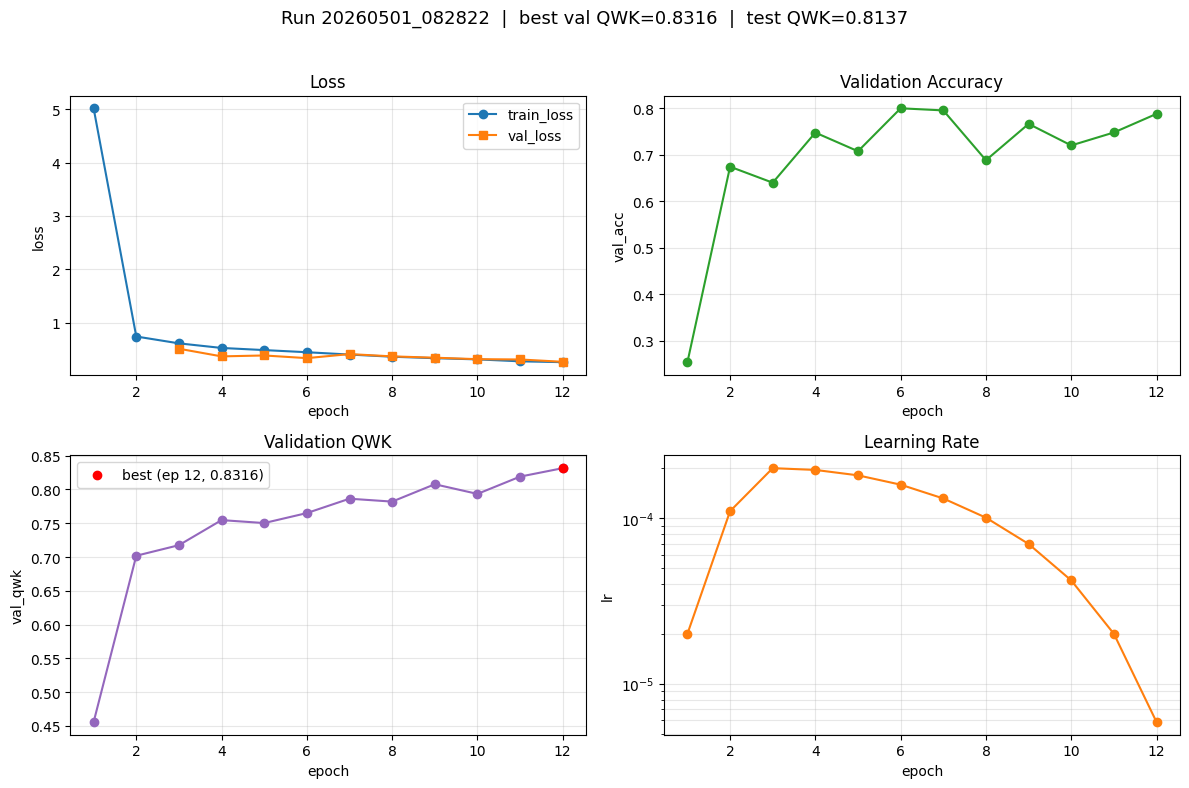

Saved logs/run_20260501_082822/curves.png


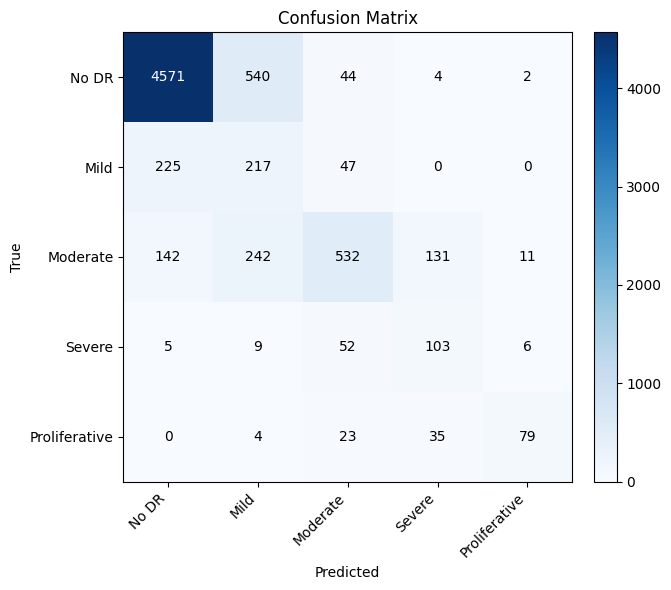

Saved logs/run_20260501_082822/confusion_matrix.png


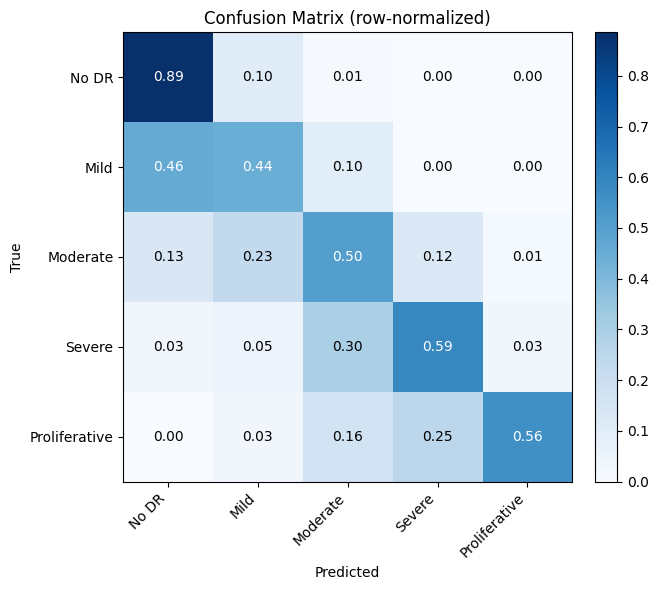

Saved logs/run_20260501_082822/confusion_matrix_norm.png


In [15]:
def load_run(run_dir):
    run_dir = Path(run_dir)
    hist = pd.read_csv(run_dir / "history.csv")
    with open(run_dir / "config.json") as f:
        cfg = json.load(f)
    summary = None
    if (run_dir / "summary.json").exists():
        with open(run_dir / "summary.json") as f:
            summary = json.load(f)
    test_res = None
    if (run_dir / "test_results.json").exists():
        with open(run_dir / "test_results.json") as f:
            test_res = json.load(f)
    return run_dir, hist, cfg, summary, test_res


def plot_run(run_dir=None):
    """Plot training curves for a run (defaults to the current RUN_DIR)."""
    if run_dir is None:
        run_dir = RUN_DIR
    run_dir, hist, cfg, summary, test_res = load_run(run_dir)

    best_epoch = summary["best_epoch"] if summary else None
    best_qwk = summary["best_qwk"] if summary else None

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    #(0,0) Loss curves
    ax = axes[0, 0]
    ax.plot(hist["epoch"], hist["train_loss"], marker="o", label="train_loss")
    ax.plot(hist["epoch"], hist["val_loss"], marker="s", label="val_loss")
    ax.set_xlabel("epoch"); ax.set_ylabel("loss")
    ax.set_title("Loss")
    ax.grid(alpha=0.3); ax.legend()

    #(0,1) Val accuracy
    ax = axes[0, 1]
    ax.plot(hist["epoch"], hist["val_acc"], marker="o", color="tab:green")
    ax.set_xlabel("epoch"); ax.set_ylabel("val_acc")
    ax.set_title("Validation Accuracy")
    ax.grid(alpha=0.3)

    #(1,0) Val QWK with best-epoch marker
    ax = axes[1, 0]
    ax.plot(hist["epoch"], hist["val_qwk"], marker="o", color="tab:purple")
    if best_epoch is not None and best_qwk is not None:
        ax.scatter([best_epoch], [best_qwk], color="red", zorder=5,
                   label=f"best (ep {best_epoch}, {best_qwk:.4f})")
        ax.legend()
    ax.set_xlabel("epoch"); ax.set_ylabel("val_qwk")
    ax.set_title("Validation QWK")
    ax.grid(alpha=0.3)

    #(1,1) LR schedule
    ax = axes[1, 1]
    ax.plot(hist["epoch"], hist["lr"], marker="o", color="tab:orange")
    ax.set_xlabel("epoch"); ax.set_ylabel("lr")
    ax.set_title("Learning Rate")
    ax.set_yscale("log")
    ax.grid(alpha=0.3, which="both")

    #Title with run metadata
    title_bits = [f"Run {cfg.get('run_ts', run_dir.name)}"]
    if best_qwk is not None:
        title_bits.append(f"best val QWK={best_qwk:.4f}")
    if test_res is not None:
        title_bits.append(f"test QWK={test_res['qwk']:.4f}")
    fig.suptitle("  |  ".join(title_bits), fontsize=13)

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    out = run_dir / "curves.png"
    fig.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")


def plot_confusion_matrix(run_dir=None, normalize=False):
    """Render the confusion matrix saved in run_dir as a heatmap."""
    if run_dir is None:
        run_dir = RUN_DIR
    run_dir = Path(run_dir)
    cm = np.loadtxt(run_dir / "confusion_matrix.csv", delimiter=",", dtype=int)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        display_cm = np.divide(cm.astype(float), row_sums, where=row_sums != 0, out=None)
        fmt = ".2f"
    else:
        display_cm = cm
        fmt = "d"

    labels = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(display_cm, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

    title = "Confusion Matrix (row-normalized)" if normalize else "Confusion Matrix"
    ax.set_title(title)

    #Annotate each cell
    thresh = display_cm.max() / 2.0 if display_cm.max() > 0 else 0.5
    for i in range(display_cm.shape[0]):
        for j in range(display_cm.shape[1]):
            val = display_cm[i, j]
            text = format(val, fmt)
            color = "white" if val > thresh else "black"
            ax.text(j, i, text, ha="center", va="center", color=color, fontsize=10)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    out = run_dir / ("confusion_matrix_norm.png" if normalize else "confusion_matrix.png")
    fig.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")


plot_run()
plot_confusion_matrix()
plot_confusion_matrix(normalize=True)

# plot_run("logs/run_20260411_233940")
# plot_confusion_matrix("logs/run_20260411_233940")
# plot_confusion_matrix("logs/run_20260411_233940", normalize=True)

## 12. Test-Time Augmentation (TTA)
At inference, apply the same random augmentations used during training (rotation,
horizontal flip, vertical flip) to each test image `N_TTA` times. Average the
regression outputs across all augmented passes, then round and clip to
`[0, NUM_CLASSES-1]` to get the final class label. This trades compute for a
typically small but consistent gain on orientation-invariant tasks like fundus grading.


In [ ]:
#TTA configuration
N_TTA = 16

#Reuses the train_transform
tta_transform = train_transform

@torch.no_grad()
def evaluate_tta(model, dataframe, transform, n_tta, criterion, device,
                 batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    """Run `n_tta` augmented passes over the dataset and average regression outputs."""
    model.eval()

    filepaths = dataframe["filepath"].tolist()
    labels = dataframe["level"].tolist()
    num_samples = len(labels)

    sum_outputs = np.zeros(num_samples, dtype=np.float64)

    for pass_idx in range(n_tta):
        ds = DRDatasetFromPaths(filepaths, labels, transform=transform)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True)

        pass_outputs = []
        for input, _ in tqdm(loader, desc=f"TTA pass {pass_idx+1}/{n_tta}", leave=False):
            input = input.to(device, non_blocking=True)
            with autocast(device_type="cuda"):
                output = model(input).squeeze(-1)
            pass_outputs.append(output.float().cpu().numpy())
        sum_outputs += np.concatenate(pass_outputs)

    mean_outputs = sum_outputs / n_tta

    y_true = np.array(labels, dtype=np.int64)
    y_pred = np.clip(np.rint(mean_outputs), 0, NUM_CLASSES - 1).astype(np.int64)

    #MSE on averaged regression outputs
    loss = float(np.mean((mean_outputs - y_true.astype(np.float64)) ** 2))

    return {
        "loss": loss,
        "acc": float((y_pred == y_true).mean()),
        "qwk": float(cohen_kappa_score(y_true, y_pred, weights="quadratic")),
        "cm": confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))),
        "y_true": y_true,
        "y_pred": y_pred,
        "outputs": mean_outputs,
    }


#Reload the best checkpoint
model.load_state_dict(torch.load(BEST_CKPT_PATH, map_location=device))

tta_start = time.time()
tta = evaluate_tta(model, test_df, tta_transform, N_TTA, criterion, device)
tta_time = time.time() - tta_start

print(f"TTA passes : {N_TTA}")
print(f"TTA loss : {tta['loss']:.4f}")
print(f"TTA acc : {tta['acc']:.4f}")
print(f"TTA QWK : {tta['qwk']:.4f}")
print(f"(no-TTA QWK : {test['qwk']:.4f}  |  Δ = {tta['qwk']-test['qwk']:+.4f})")

print("\nTTA confusion matrix (row-normalized, rows=true, cols=pred):")
tta_cm_row_sums = tta["cm"].sum(axis=1, keepdims=True)
tta_cm_norm = np.divide(
    tta["cm"].astype(float), tta_cm_row_sums,
    out=np.zeros_like(tta["cm"], dtype=float), where=tta_cm_row_sums != 0,
)
tta_cm_df = pd.DataFrame(
    tta_cm_norm,
    index=[f"true_{i}" for i in range(NUM_CLASSES)],
    columns=[f"pred_{i}" for i in range(NUM_CLASSES)],
)
print(tta_cm_df.round(4))

#Persist TTA results alongside the run
tta_results = {
    "n_tta": N_TTA,
    "loss": tta["loss"],
    "acc": tta["acc"],
    "qwk": tta["qwk"],
    "no_tta_qwk": float(test["qwk"]),
    "qwk_delta": float(tta["qwk"] - test["qwk"]),
    "ckpt_path": BEST_CKPT_PATH,
    "eval_time_s": round(tta_time, 2),
    "evaluated_at": datetime.datetime.now().isoformat(timespec="seconds"),
}
with open(RUN_DIR / "tta_results.json", "w") as f:
    json.dump(tta_results, f, indent=2)
np.savetxt(RUN_DIR / "tta_confusion_matrix.csv", tta["cm"], fmt="%d", delimiter=",")
np.savez(RUN_DIR / "tta_predictions.npz",
         y_true=tta["y_true"], y_pred=tta["y_pred"], outputs=tta["outputs"])

print(f"\nTTA results written: {RUN_DIR/'tta_results.json'}")


TTA pass 2/16:  13%|█▎        | 57/439 [00:05<00:33, 11.55it/s] 

In [ ]:
def visualize_tta_predictions(model, dataframe, transform, n_tta, device,
                                samples_per_class=1, seed=0, save_dir=None):
    """For a few sample images, show every augmented pass + the averaged regression output."""
    model.eval()
    if save_dir is None:
        save_dir = RUN_DIR
    save_dir = Path(save_dir)

    rng = np.random.default_rng(seed)
    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)
    class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

    def denorm(t):
        img = t.cpu().numpy().transpose(1, 2, 0)
        return np.clip(img * std + mean, 0.0, 1.0)

    def to_class(x):
        return int(np.clip(np.rint(x), 0, NUM_CLASSES - 1))

    #Pick `samples_per_class` examples from each class
    picks = []
    for cls in range(NUM_CLASSES):
        cls_df = dataframe[dataframe["level"] == cls]
        if len(cls_df) == 0:
            continue
        idx = rng.choice(len(cls_df), size=min(samples_per_class, len(cls_df)), replace=False)
        for i in idx:
            picks.append(cls_df.iloc[int(i)])

    for row in picks:
        img = Image.open(row["filepath"]).convert("RGB")
        true_label = int(row["level"])

        aug_tensors = [transform(img) for _ in range(n_tta)]
        batch = torch.stack(aug_tensors).to(device)

        with torch.no_grad(), autocast(device_type="cuda"):
            output = model(batch).squeeze(-1)
        outputs = output.float().cpu().numpy()
        avg_output = float(outputs.mean())
        avg_pred = to_class(avg_output)

        ncols = 4
        n_tiles = n_tta + 1  #augmentations + final summary tile
        nrows = int(np.ceil(n_tiles / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.4 * nrows))
        axes = np.array(axes).flatten()

        for i, t in enumerate(aug_tensors):
            ax = axes[i]
            ax.imshow(denorm(t))
            out_i = float(outputs[i])
            pred_i = to_class(out_i)
            color = "green" if pred_i == true_label else "red"
            ax.set_title(f"aug {i+1}: out={out_i:.2f} -> {pred_i}",
                         fontsize=9, color=color)
            ax.axis("off")

        #Final summary: per-pass regression outputs as a strip plot, plus the average
        ax_last = axes[n_tta]
        ax_last.scatter(range(n_tta), outputs, color="tab:blue", alpha=0.7, label="per-pass")
        ax_last.axhline(avg_output, color="tab:red", linestyle="-",
                        label=f"avg={avg_output:.2f}")
        ax_last.axhline(true_label, color="green", linestyle="--", alpha=0.6,
                        label=f"true={true_label}")
        ax_last.set_ylim(-0.5, NUM_CLASSES - 0.5)
        ax_last.set_yticks(range(NUM_CLASSES))
        ax_last.set_xlabel("TTA pass"); ax_last.set_ylabel("regression output")
        ax_last.set_title(f"avg (TTA={n_tta}): {avg_output:.2f} -> {avg_pred}",
                          fontsize=9, color=("green" if avg_pred == true_label else "red"))
        ax_last.legend(fontsize=8, loc="upper right")
        ax_last.grid(alpha=0.3)

        #Hide any unused axes
        for j in range(n_tta + 1, len(axes)):
            axes[j].axis("off")

        correct = avg_pred == true_label
        fig.suptitle(
            f"{Path(row['filepath']).name}  "
            f"true={true_label} ({class_names[true_label]})  "
            f"avg_pred={avg_pred} ({class_names[avg_pred]})  "
            f"avg_output={avg_output:.3f}  "
            f"{'OK' if correct else 'MISS'}",
            fontsize=11, color=("green" if correct else "red"),
        )
        fig.tight_layout(rect=[0, 0, 1, 0.94])
        out = save_dir / f"tta_sample_cls{true_label}_{Path(row['filepath']).stem}.png"
        fig.savefig(out, dpi=100, bbox_inches="tight")
        plt.show()
        print(f"Saved {out}")


visualize_tta_predictions(model, test_df, tta_transform, N_TTA, device, samples_per_class=1, seed=42)
